UAS PENGOLAHAN CITRA DIGITAL

ARYA SETYAKI - 202331309

VIA GOOGLE COLABS

In [1]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files
import io

In [2]:
uploaded = files.upload()

Saving fotodiri.jpeg to fotodiri.jpeg


In [3]:
img_cv = None
filename = None

for name, content in uploaded.items():
    filename = name
    # Baca dengan OpenCV
    nparr = np.frombuffer(content, np.uint8)
    img_cv = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
    print(f" Gambar berhasil diupload: {name}")
    break

if img_cv is None:
    print(" Gagal upload gambar. Silakan coba lagi.")
    exit()

 Gambar berhasil diupload: fotodiri.jpeg


In [4]:
img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
height, width = img_cv.shape[:2]
print(f" Dimensi gambar: {width} x {height} piksel")
print(f" Mode warna: RGB ({img_rgb.shape[2]} channel)")

 Dimensi gambar: 720 x 1600 piksel
 Mode warna: RGB (3 channel)


In [5]:
def display_grid(images, titles, rows, cols, figsize=(15, 10)):
    """Menampilkan grid gambar dengan judul"""
    fig, axes = plt.subplots(rows, cols, figsize=figsize)


    if isinstance(axes, plt.Axes):
        axes_flat = [axes]
    elif isinstance(axes, np.ndarray):
        axes_flat = axes.flatten().tolist()
    else:

        axes_flat = list(axes)

    for i, (img, title) in enumerate(zip(images, titles)):
        if i < len(axes_flat):
            axes_flat[i].imshow(img)
            axes_flat[i].set_title(title, fontsize=12, fontweight='bold', pad=10)
            axes_flat[i].axis('off')

    # Sembunyikan axes kosong
    for j in range(len(images), len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    plt.show()

def save_image(img, name):
    """Simpan gambar ke file"""
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    cv2.imwrite(name, img_bgr)
    print(f"Disimpan: {name}")

CITRA ASLI


1. CITRA ASLI


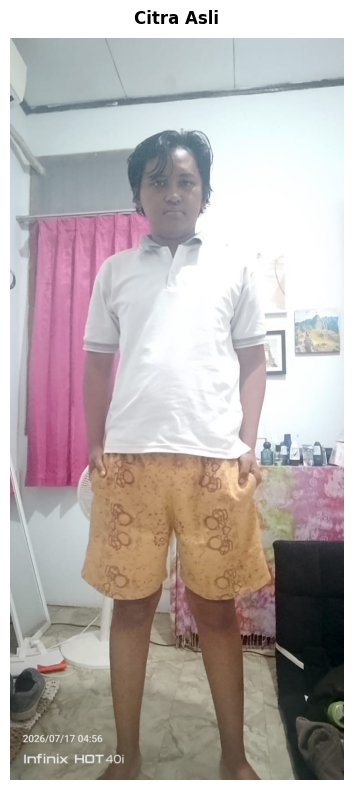

In [6]:
original = img_rgb.copy()
print("\n" + "="*60)
print("1. CITRA ASLI")
print("="*60)
display_grid([original], ["Citra Asli"], 1, 1, figsize=(8, 8))

ROTASI


2. ROTATED (Rotasi Gambar)


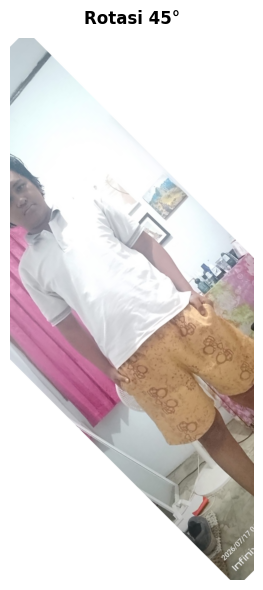

In [7]:
def rotate_image(img, angle):
    """Rotasi gambar dengan sudut tertentu"""
    h, w = img.shape[:2]
    center = (w // 2, h // 2)
    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(img, rotation_matrix, (w, h),
                             borderMode=cv2.BORDER_CONSTANT,
                             borderValue=(255, 255, 255))
    return rotated

rotated_45 = rotate_image(img_rgb, 45)

print("\n" + "="*60)
print("2. ROTATED (Rotasi Gambar)")
print("="*60)
display_grid(
    [rotated_45],
    ["Rotasi 45°"],
    1, 1, figsize=(15, 6)
)


RESIZED


3. RESIZED (Ubah Ukuran)


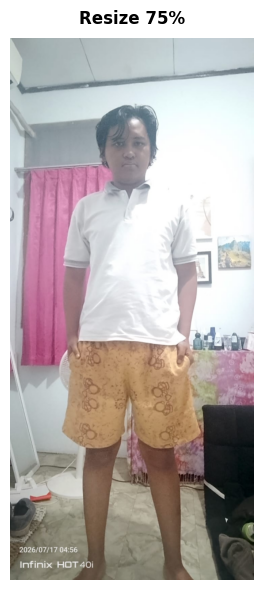

In [8]:
def resize_image(img, scale_percent):
    """Ubah ukuran gambar dengan skala persentase"""
    w = int(img.shape[1] * scale_percent / 100)
    h = int(img.shape[0] * scale_percent / 100)
    resized = cv2.resize(img, (w, h), interpolation=cv2.INTER_AREA)
    return resized

resized_75 = resize_image(img_rgb, 75)

print("\n" + "="*60)
print("3. RESIZED (Ubah Ukuran)")
print("="*60)
display_grid(
    [resized_75],
    ["Resize 75%"],
    1, 1, figsize=(15, 6)
)


CROPPED


4. CROPPED (Pemotongan Gambar)


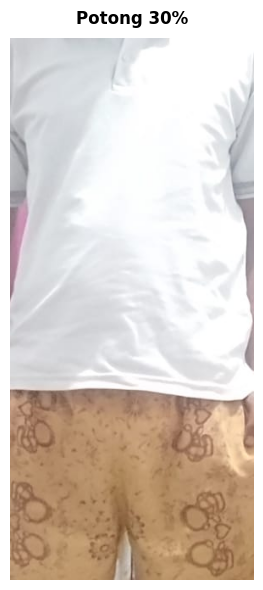

In [9]:
def crop_image(img, crop_percent):
    """Potong gambar dengan persentase dari setiap sisi"""
    h, w = img.shape[:2]
    crop_h = int(h * crop_percent / 100)
    crop_w = int(w * crop_percent / 100)
    cropped = img[crop_h:h-crop_h, crop_w:w-crop_w]
    return cropped

cropped_30 = crop_image(img_rgb, 30)

print("\n" + "="*60)
print("4. CROPPED (Pemotongan Gambar)")
print("="*60)
display_grid(
    [cropped_30],
    ["Potong 30%"],
    1, 1, figsize=(15, 6)
)


FLIPPED


5. FLIPPED (Pembalikan Gambar)


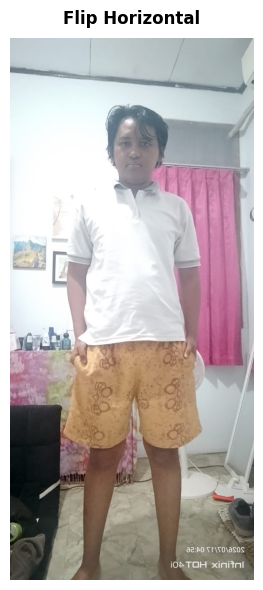

In [10]:
flipped_h = cv2.flip(img_rgb, 1)   # Horizontal

print("\n" + "="*60)
print("5. FLIPPED (Pembalikan Gambar)")
print("="*60)
display_grid(
    [flipped_h],
    ["Flip Horizontal"],
    1, 1, figsize=(15, 6)
)

TRANSLATED/TRANSLASI


6. TRANSLATED (Pergeseran Gambar)


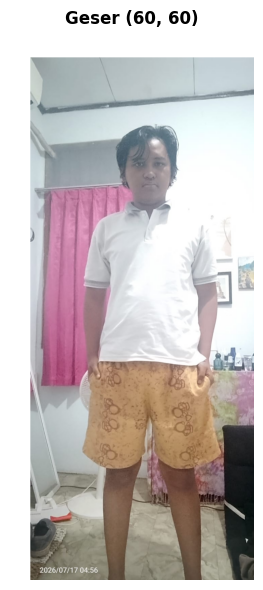

In [11]:
def translate_image(img, tx, ty):
    """Geser gambar dengan translasi tx, ty"""
    h, w = img.shape[:2]
    translation_matrix = np.float32([[1, 0, tx], [0, 1, ty]])
    translated = cv2.warpAffine(img, translation_matrix, (w, h),
                                borderMode=cv2.BORDER_CONSTANT,
                                borderValue=(255, 255, 255))
    return translated

translated_60_60 = translate_image(img_rgb, 60, 60)

print("\n" + "="*60)
print("6. TRANSLATED (Pergeseran Gambar)")
print("="*60)
display_grid(
    [translated_60_60],
    ["Geser (60, 60)"],
    1, 1, figsize=(15, 6)
)


RESULT/HASIL


RINGKASAN SEMUA TRANSFORMASI


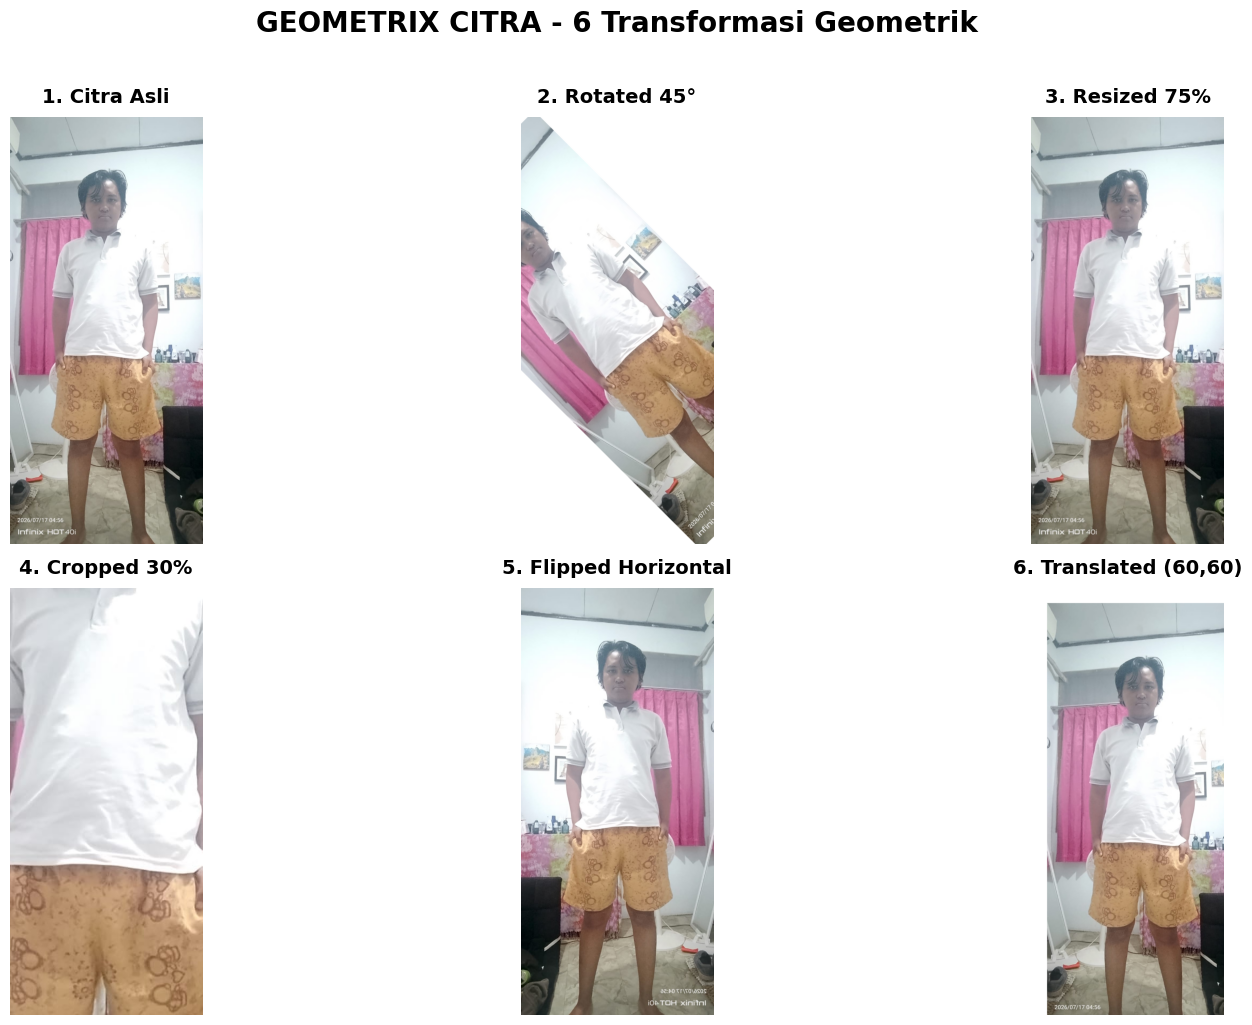

In [12]:
print("\n" + "="*60)
print("RINGKASAN SEMUA TRANSFORMASI")
print("="*60)

all_images = [
    original,
    rotated_45,
    resized_75,
    cropped_30,
    flipped_h,
    translated_60_60
]

all_titles = [
    "1. Citra Asli",
    "2. Rotated 45°",
    "3. Resized 75%",
    "4. Cropped 30%",
    "5. Flipped Horizontal",
    "6. Translated (60,60)"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (img, title) in enumerate(zip(all_images, all_titles)):
    axes[i].imshow(img)
    axes[i].set_title(title, fontsize=14, fontweight='bold', pad=10)
    axes[i].axis('off')

plt.suptitle("GEOMETRIX CITRA - 6 Transformasi Geometrik",
             fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
